X Variable name 
Gradient  =  0.01301414108132448  +/-  0.00032904258413160516
Intercept =  1.5999902893529965  +/-  0.0013950867291552833


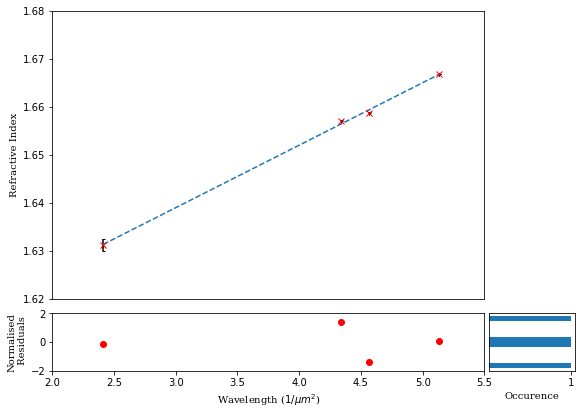

In [1]:
excel_name = "prism spectrometer edit3"
x_variable_name = str(input("X Variable name "))

excel_name_fix = excel_name + ".xlsx"

import statistics as stats

from scipy.stats import norm 
import scipy.optimize as scpo 
#for curve fitting

import numpy as np 
#most numerical operations

import matplotlib.pyplot as plt
#all other graphing realated stuff 

import pandas as pd 
#import and export excel data and manipulating it 

import datetime as d
#for asigning timestamps to graph exports

#>>>IMPORTANT<<<#
#File (spreadsheet) must be in the same folder as the notebook is!!
#Jupyter cannot edit spreadsheets - get it prepped beforehand

sp = pd.read_excel(excel_name_fix)
x_variable = sp['1/wavelength squared '].values #NOTE: The column MUST have lable at the very top row (A), not just any row!
x_errors = sp['Error 1/wavelength squared '].values

y1_variable = sp['refractive index'].values
y1_error = sp['error refractive index'].values
#Copy for as many y variable as needed NEED TO CHANGE NUMBER AFTER 'Y'

def Line(x, grad, intercept): 
    y = grad*x + intercept
    return y

actual_fit_parameters, covariance_matrix = scpo.curve_fit(Line, x_variable, y1_variable)

fit_gradient = actual_fit_parameters[0] 
fit_intercept = actual_fit_parameters[1]

y_values_best_fit = Line(x_variable, fit_gradient, fit_intercept)

plt.figure(1).add_axes((0,0,1,1)) #This is the start of the code to draw graph: figure 1 

plt.errorbar(x_variable, y1_variable, xerr = x_errors, yerr = y1_error, fmt = 'x', color = 'red', ecolor = 'black', capsize = 1.5)

plt.plot(x_variable, y_values_best_fit, ls ='--')
plt.gca().axes.get_xaxis().set_ticks([])

#>>>HERE FOR ASTHETICS<<<#
ff = 'serif' #Font family
plt.ylabel("Refractive Index", family = ff)

plt.gca().set_xlim([2,5.5]) #x-axis limits
plt.gca().set_ylim([1.62,1.68]) #y-axis limits

#Residuals 

plt.figure(1).add_axes((0.0,-0.25,1,0.2))

y1_residuals = y1_variable - y_values_best_fit

y1_residuals_normalised = y1_residuals/np.std(y1_residuals)

mean_y1_r_n = stats.mean(y1_residuals_normalised)
sd_y1_r_n = stats.stdev(y1_residuals_normalised)

plt.scatter(x_variable,y1_residuals_normalised, color ='red')
plt.gca().set_ylim([-2,2])
plt.ylabel("Normalised\n Residuals", family = ff)

plt.xlabel("Wavelength ($ 1/ \mu m ^{2} $)",family = ff)
plt.gca().set_xlim([2,5.5])
plt.figure(1).add_axes((1.01,-0.25,0.2,0.2))
plt.hist(y1_residuals_normalised, orientation = "horizontal")
#plt.plot(norm.pdf(y1_residuals_normalised, mean_y1_r_n, sd_y1_r_n))
plt.gca().axes.get_yaxis().set_ticks([])
plt.gca().axes.get_xaxis().set_ticks([1])
plt.xlabel("Occurence", family = ff)

print("Gradient  = ",fit_gradient," +/- ", np.sqrt(covariance_matrix[0,0]))
print("Intercept = ",fit_intercept, " +/- ", np.sqrt(covariance_matrix[1,1]))

#EXPORTING 
time = d.datetime.now()
export_name = excel_name + " " + str(time) + ".png"
plt.savefig(export_name, dpi = 1000, bbox_inches = 'tight') 
#saves file as the excel file 
#name (without file extention) WITH time at saving instance

In [52]:
import numpy as np

np.std(np.arange(1,20))

5.477225575051661